In [1]:
import torch
torch.__version__


'2.9.0+cu126'

In [2]:
!pip install torch-geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.2 MB/s eta 0:00:00


✅ Loaded 141 samples in total.

📊 Dataset count BEFORE SMOTE:
Total samples: 141
CN: 59
EMCI: 28
LMCI: 28
AD: 26

📊 Dataset count AFTER SMOTE:
Total samples: 236
CN: 59
EMCI: 59
LMCI: 59
AD: 59

================ FOLD 1 ================

Training samples in this fold: 188
Testing  samples in this fold: 48

================ FOLD 2 ================

Training samples in this fold: 189
Testing  samples in this fold: 47

================ FOLD 3 ================

Training samples in this fold: 189
Testing  samples in this fold: 47

================ FOLD 4 ================

Training samples in this fold: 189
Testing  samples in this fold: 47

================ FOLD 5 ================

Training samples in this fold: 189
Testing  samples in this fold: 47

✅ Model saved at: /content/drive/MyDrive/NEUROVISTA-PROJECT/OUR-MODELS/4CLASS-MODEL/4class_weights_final_77_54.pt
🎯 Final Accuracy (all folds): 77.54%


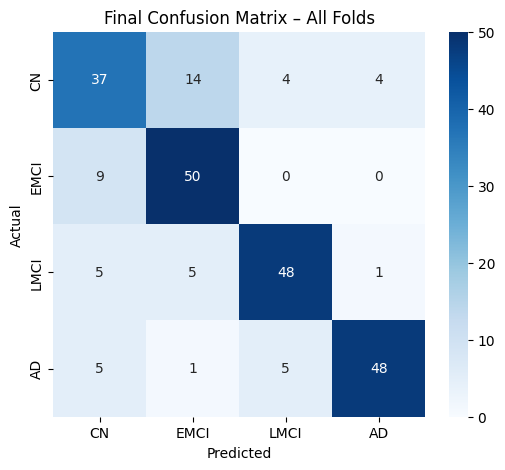

In [5]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE



DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_NODES = 116
EPOCHS = 50
LR = 1e-3
N_SPLITS = 5
CLASS_NAMES = ['CN','EMCI','LMCI','AD']

EXPORT_DIR = "/content/drive/MyDrive/NEUROVISTA-PROJECT/OUR-MODELS/4CLASS-MODEL"
os.makedirs(EXPORT_DIR, exist_ok=True)


def load_data(base_path):
    classes = {'CN':0,'EMCI':1,'LMCI':2,'AD':3}
    X, y = [], []

    for c, lab in classes.items():
        pdir = os.path.join(base_path, f"{c}_graphs", "Graph_Output")
        gdir = os.path.join(base_path, f"{c}_graphs", "Graph_Output_Granger")
        wdir = os.path.join(base_path, f"{c}_graphs", "Graph_Output_Coherence")

        if not (os.path.exists(pdir) and os.path.exists(gdir) and os.path.exists(wdir)):
            print(f"❌ Missing folders for class {c}")
            continue

        for f in os.listdir(pdir):
            if not f.endswith(".npy"):
                continue

            sid = f.replace("_corr_matrix.npy","")
            gp = os.path.join(gdir,f"{sid}_granger_matrix.npy")
            wp = os.path.join(wdir,f"{sid}_coherence_matrix.npy")

            if not (os.path.exists(gp) and os.path.exists(wp)):
                continue

            try:
                p = np.nan_to_num(np.load(os.path.join(pdir,f)))
                g = np.nan_to_num(np.load(gp))
                w = np.nan_to_num(np.load(wp))
                X.append(np.hstack([p.flatten(), g.flatten(), w.flatten()]))
                y.append(lab)
            except:
                continue

    if len(X) == 0:
        raise ValueError("No data loaded! Check folder paths and .npy files.")

    X = np.array(X)
    y = np.array(y)
    print(f"✅ Loaded {len(X)} samples in total.")
    return X, y


class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 4)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


def run_kfold(base_path):

    X, y = load_data(base_path)


    print("\n📊 Dataset count BEFORE SMOTE:")
    print(f"Total samples: {len(y)}")
    for cls in np.unique(y):
        print(f"{CLASS_NAMES[cls]}: {(y==cls).sum()}")

    X = StandardScaler().fit_transform(X)

    sm = SMOTE(random_state=42, k_neighbors=3)
    X_res, y_res = sm.fit_resample(X, y)


    print("\n📊 Dataset count AFTER SMOTE:")
    print(f"Total samples: {len(y_res)}")
    for cls in np.unique(y_res):
        print(f"{CLASS_NAMES[cls]}: {(y_res==cls).sum()}")

    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

    all_preds = []
    all_trues = []
    fold_acc = []

    best_acc = 0.0
    best_model_state = None

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_res)):
        print(f"\n================ FOLD {fold+1} ================\n")

        print(f"Training samples in this fold: {len(train_idx)}")
        print(f"Testing  samples in this fold: {len(test_idx)}")

        X_train = torch.tensor(X_res[train_idx], dtype=torch.float32, device=DEVICE)
        y_train = torch.tensor(y_res[train_idx], dtype=torch.long, device=DEVICE)
        X_test = torch.tensor(X_res[test_idx], dtype=torch.float32, device=DEVICE)
        y_test = torch.tensor(y_res[test_idx], dtype=torch.long, device=DEVICE)

        model = SimpleNN(X_train.shape[1]).to(DEVICE)
        opt = torch.optim.Adam(model.parameters(), lr=LR)
        criterion = nn.CrossEntropyLoss()

        model.train()
        for ep in range(EPOCHS):
            opt.zero_grad()
            out = model(X_train)
            loss = criterion(out, y_train)
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            out = model(X_test)
            preds = out.argmax(dim=1).cpu().numpy()
            trues = y_test.cpu().numpy()

            acc = accuracy_score(trues, preds)
            fold_acc.append(acc)
            all_preds.extend(preds)
            all_trues.extend(trues)

            if acc > best_acc:
                best_acc = acc
                best_model_state = model.state_dict()

    final_acc = accuracy_score(all_trues, all_preds)
    final_acc_pct = round(final_acc * 100, 2)

    model_name = f"4class_weights_final_{str(final_acc_pct).replace('.', '_')}.pt"
    model_path = os.path.join(EXPORT_DIR, model_name)

    torch.save({
        "model_state": best_model_state,
        "input_dim": X.shape[1],
        "class_names": CLASS_NAMES,
        "final_accuracy": final_acc_pct
    }, model_path)

    print(f"\n✅ Model saved at: {model_path}")
    print(f"🎯 Final Accuracy (all folds): {final_acc_pct}%")

    cm = confusion_matrix(all_trues, all_preds)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Final Confusion Matrix – All Folds")
    plt.show()


base_path = "/content/drive/MyDrive/NEUROVISTA-PROJECT/All_GRAPHS_Unzipped"
run_kfold(base_path)
